Check that the formula for the gradient is correctly calculating it for an analytic function, such as $f(r,\theta) = r\sin 2\theta$, comparing Cartesian and polar gradients.

[[0.15682198 0.26940679 0.15590226 ... 0.00408194 0.00404038 0.00399966]
 [0.26940679 1.21124729 0.89074608 ... 0.02465373 0.02440277 0.02415692]
 [0.15590226 0.89074608 1.07408073 ... 0.04520974 0.04474986 0.04429956]
 ...
 [0.00408194 0.02465373 0.04520974 ... 1.00003969 0.99998689 1.00360946]
 [0.00404038 0.02440277 0.04474986 ... 0.99998689 1.00003889 1.00376692]
 [0.00399966 0.02415692 0.04429956 ... 1.00360946 1.00376692 1.00759879]]


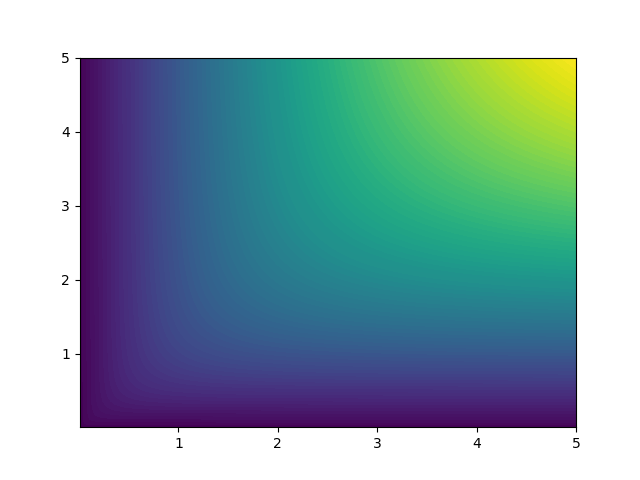

In [107]:
import numpy as np
from matplotlib import pyplot as plt
x = np.linspace(0.01,5,100)
y = np.linspace(0.01,5,100)
xg,yg = np.meshgrid(x,y)

rg = np.sqrt(xg**2 + yg**2)
thg = np.arctan(yg/xg)

fg = rg*np.sin(thg*2)

fig,ax = plt.subplots()
ax.contourf(xg,yg,fg,levels=100)
plt.show()

So we want to calculate the change in f between two points $(x_0,y_0)$ and $(x_1,y_1)$ (which in polar coordinates are $(r_0,\theta_0)$ and $(r_1,\theta_1)$). 
The change in $f$ is:
$$
d\mathrm{f} = d\mathrm{\mathbf{r}} \cdot \nabla f 
$$
In this case, we are interested in a $d\mathrm{\mathbf{r}}$ that is in the direction of the gradient of $f$, i.e. $d\mathrm{\mathbf{r}} = \nabla f/|\nabla f|$

1.4814755080140878 1.6697437227955725 1.6697437227955727


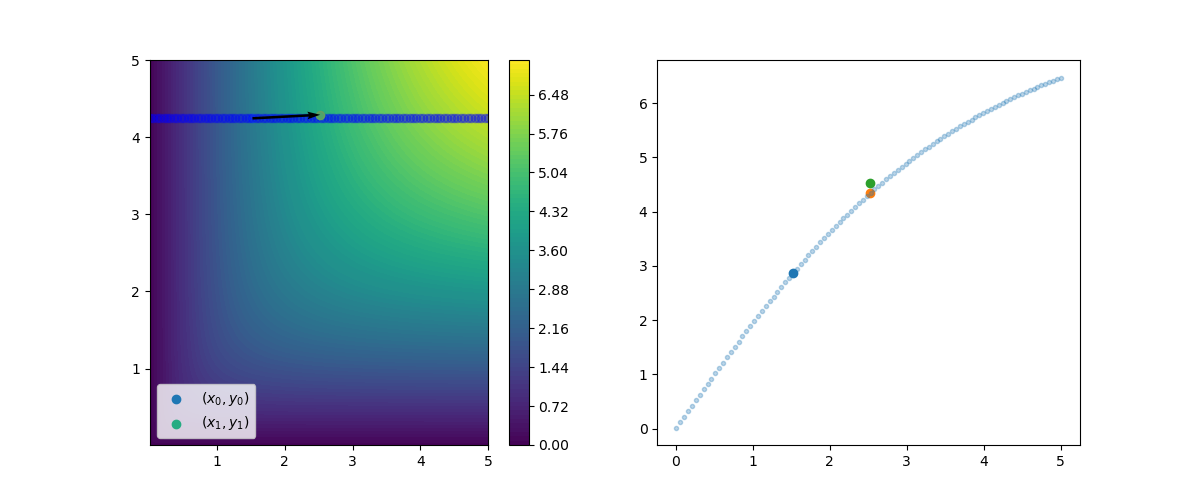

In [132]:
%matplotlib widget
from scipy.interpolate import interpn
grady,gradx = np.gradient(fg,y,x)

i0 = 84
j0 = 30
gradf = np.sqrt(gradx**2 + grady**2)

x0 = xg[i0,j0]
y0 = yg[i0,j0]

u = gradx[i0,j0]/gradf[i0,j0]
v = grady[i0,j0]/gradf[i0,j0]

x1 = xg[i0,j0] + u
y1 = yg[i0,j0] + v

th1_check = np.arctan(y1/x1)

dx = x1 - x0
dy = y1 - y0

points = (y,x)
values = fg
point = (y1,x1)
f_interp = interpn(points,values,point)

delta_f = f_interp - fg[i0,j0]
dxi = np.sqrt(dx**2 + dy**2)
df = 1./gradf[i0,j0]*(gradx[i0,j0]*gradx[i0,j0] + grady[i0,j0]*grady[i0,j0])*dxi
df2 = gradx[i0,j0]*dx + grady[i0,j0]*dy
print(delta_f[0], df,df2)

fig,(ax,ax2) = plt.subplots(1,2, figsize = (12,5))
cb=ax.contourf(xg,yg,fg,levels=100)
ax.scatter(x0,y0,label=r"$(x_0,y_0)$")
ax.scatter(xg[i0,:],yg[i0,:],alpha = 0.3, c= 'b')
ax.scatter(x1,y1,label=r"$(x_1,y_1)$", c = f_interp,vmin=np.min(fg),vmax = np.max(fg))
ax.scatter(x1,y1,alpha = 0.2)
ax.quiver(x0,y0,u,v,angles='xy',scale_units='xy',scale=1)
ax.legend()
fig.colorbar(cb)
ax2.plot(xg[i0,:],fg[i0,:],'.',alpha = 0.3)
ax2.scatter(xg[i0,j0],fg[i0,j0])
ax2.scatter(x1,f_interp)
ax2.scatter(x1,fg[i0,j0] + df)
# ax2.scatter(x1,fg[i0,j0] + df2)
plt.show()

Now check the same in polar coordinates:

[1.48147551] 1.6697437227955725 1.6697437227955727 1.6697437227955718


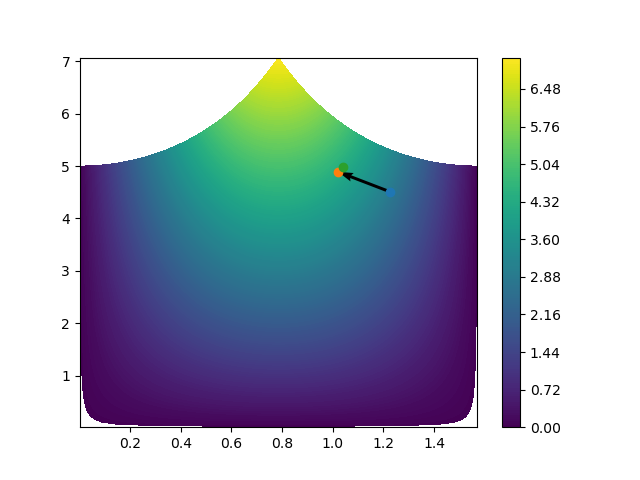

In [134]:
r0 = np.sqrt(x0**2 + y0**2)
th0 = np.arctan(y0/x0)

gradr = np.cos(thg)*gradx + np.sin(thg)*grady
gradth = -rg*np.sin(thg)*gradx + rg*np.cos(thg)*grady
gradf_rth = np.sqrt(gradr**2 + (gradth/rg)**2)

u_rth = 1/r0*gradth[i0,j0]/gradf_rth[i0,j0]
v_rth = gradr[i0,j0]/gradf_rth[i0,j0]

r1 = r0 + v_rth
th1 = th0 + u_rth/r0

dr = r1-r0
dth = th1-th0

x1_r = r1*np.cos(th1)
y1_r = r1*np.sin(th1)

r1_check = np.sqrt(x1**2 + y1**2)

# now find df
dxi = np.sqrt(dr**2 + r0**2*dth**2)

df_rth = 1./gradf_rth[i0,j0]*(gradr[i0,j0]*gradr[i0,j0] + 1./r0**2*gradth[i0,j0]*gradth[i0,j0])*dxi
print(delta_f, df,df2,df_rth)

fig,ax = plt.subplots()
cb=ax.contourf(thg,rg,fg,levels=200)
ax.quiver(th0,r0,u_rth/r0,v_rth,angles='xy',scale_units='xy',scale=1)
ax.scatter(th0,r0)
ax.scatter(th1,r1)
ax.scatter(th1_check,r1_check)
fig.colorbar(cb)
plt.show()
